# 01 — Analyse exploratoire : FD001

**Objectif** : caractériser la dynamique de dégradation des moteurs à partir des mesures capteurs — distribution des durées de vie, identification des capteurs informatifs versus constants, corrélation entre capteurs et dégradation, et écart entre trajectoires d'entraînement (complètes) et de test (tronquées).

Cette analyse conditionne les choix faits dans `02_preparation` (filtrage des capteurs) et `03_feature_engineering` (sélection des capteurs pertinents pour les fenêtres glissantes).

In [1]:
# --- Imports et configuration ---
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Rendre le package src/ importable depuis le notebook
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_subset, SENSOR_COLUMNS, SETTING_COLUMNS

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SUBSET = "FD001"

In [2]:
df_train, df_test, df_rul = load_subset(SUBSET)

print(f"train : {df_train.shape}")
print(f"test  : {df_test.shape}")
print(f"rul   : {df_rul.shape}")

train : (20631, 26)
test  : (13096, 26)
rul   : (100, 1)


## 1. Distribution des durées de vie des moteurs (train)

Le nombre de cycles avant panne varie d'un moteur à l'autre — une usure initiale légèrement différente est simulée à la fabrication. Cette variabilité motive l'écrêtage de la cible RUL utilisé plus loin dans la pipeline (au-delà d'un certain seuil, distinguer 300 cycles restants de 280 n'apporte pas d'information exploitable).

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64


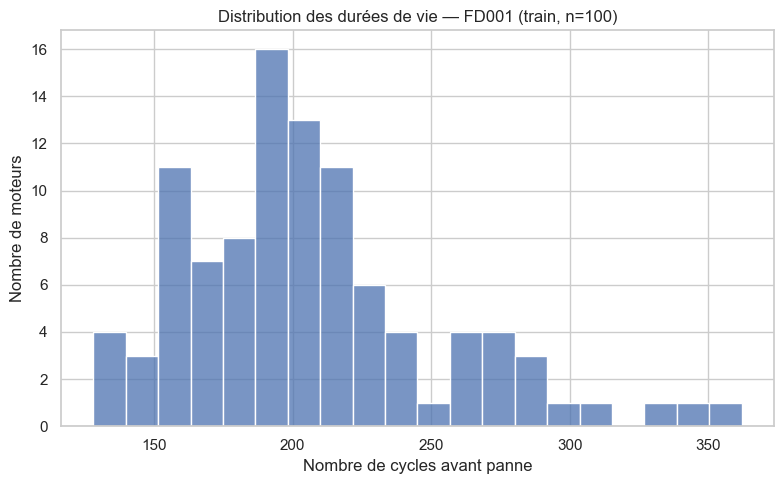

In [3]:
cycles_par_moteur = df_train.groupby("unit_number")["time_in_cycles"].max()

print(cycles_par_moteur.describe())

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(cycles_par_moteur, bins=20, ax=ax, color="#4C72B0")
ax.set_xlabel("Nombre de cycles avant panne")
ax.set_ylabel("Nombre de moteurs")
ax.set_title(f"Distribution des durées de vie — {SUBSET} (train, n={len(cycles_par_moteur)})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "distribution_duree_vie.png")
plt.show()

## 2. Tendances des capteurs au fil de la dégradation

On visualise l'évolution de quelques capteurs représentatifs pour un échantillon de moteurs, en exprimant le cycle en pourcentage de la durée de vie totale du moteur — ce qui permet de superposer des trajectoires de longueurs différentes sur un même axe et de comparer leur forme.

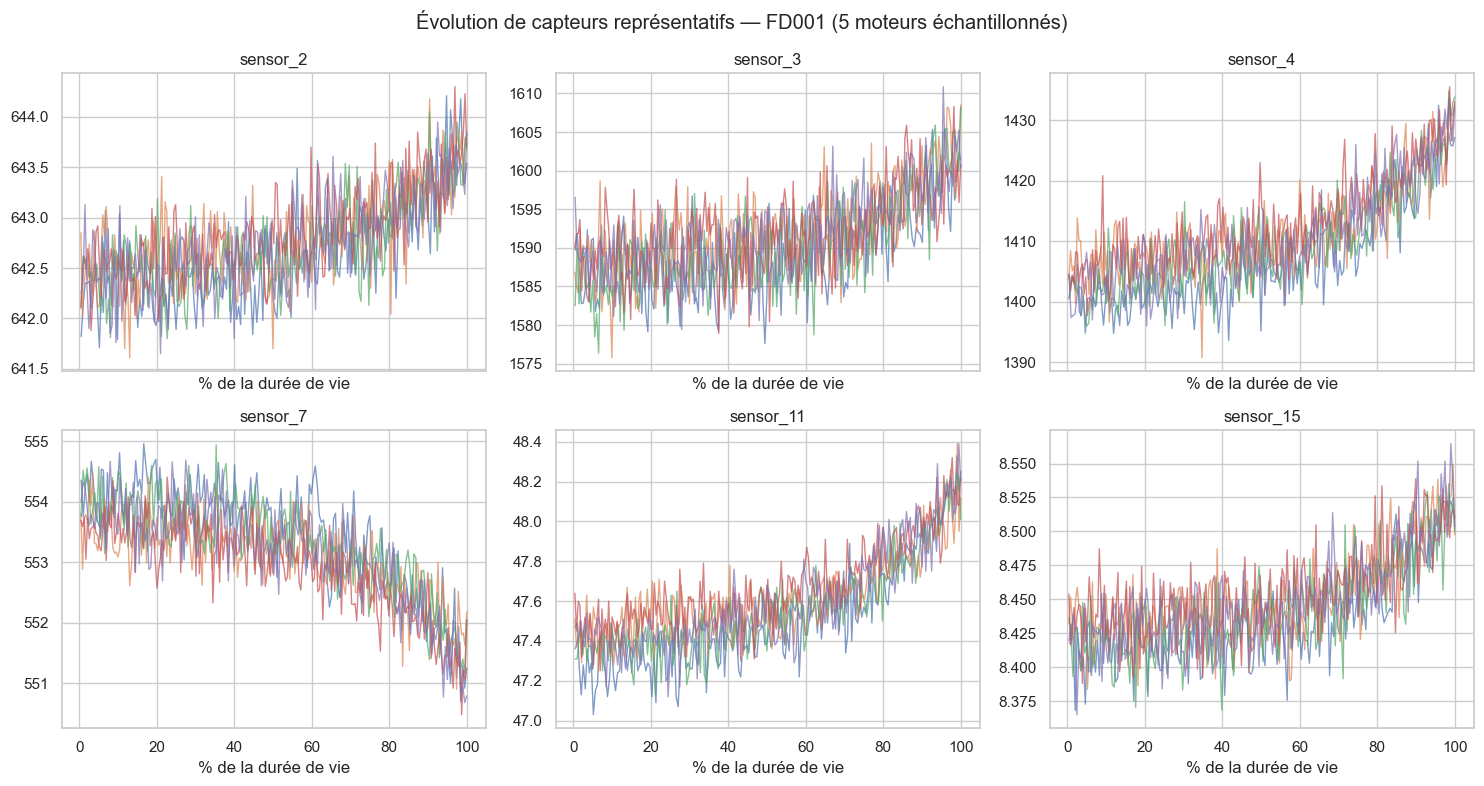

In [4]:
SAMPLE_ENGINES = [1, 25, 50, 75, 100]
SENSORS_TO_PLOT = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_11", "sensor_15"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

for sensor, ax in zip(SENSORS_TO_PLOT, axes.flat):
    for engine_id in SAMPLE_ENGINES:
        engine_data = df_train[df_train["unit_number"] == engine_id]
        vie_pct = 100 * engine_data["time_in_cycles"] / engine_data["time_in_cycles"].max()
        ax.plot(vie_pct, engine_data[sensor], alpha=0.7, linewidth=1)
    ax.set_title(sensor)
    ax.set_xlabel("% de la durée de vie")

fig.suptitle(f"Évolution de capteurs représentatifs — {SUBSET} (5 moteurs échantillonnés)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tendances_capteurs.png")
plt.show()

## 3. Détection des capteurs à variance nulle ou quasi nulle

Sur FD001 (condition opérationnelle unique), certains capteurs et réglages opérationnels restent quasiment constants sur toute la durée de vie des moteurs : ils n'apportent aucune information pour la prédiction et seront exclus dans `02_preparation`.

In [5]:
variabilite = df_train[SETTING_COLUMNS + SENSOR_COLUMNS].std().sort_values()

SEUIL_VARIANCE_NULLE = 1e-5
capteurs_constants = variabilite[variabilite < SEUIL_VARIANCE_NULLE].index.tolist()

print("Ecart-type par colonne (croissant) :")
print(variabilite)
print()
print(f"Colonnes a variance quasi nulle (std < {SEUIL_VARIANCE_NULLE}) :")
print(capteurs_constants)

Ecart-type par colonne (croissant) :
sensor_1        0.000000e+00
op_setting_3    0.000000e+00
sensor_10       0.000000e+00
sensor_19       0.000000e+00
sensor_18       0.000000e+00
sensor_16       1.387812e-17
sensor_5        1.776400e-15
op_setting_2    2.930621e-04
sensor_6        1.388985e-03
op_setting_1    2.187313e-03
sensor_15       3.750504e-02
sensor_8        7.098548e-02
sensor_13       7.191892e-02
sensor_21       1.082509e-01
sensor_20       1.807464e-01
sensor_11       2.670874e-01
sensor_2        5.000533e-01
sensor_12       7.375534e-01
sensor_7        8.850923e-01
sensor_17       1.548763e+00
sensor_3        6.131150e+00
sensor_4        9.000605e+00
sensor_14       1.907618e+01
sensor_9        2.208288e+01
dtype: float64

Colonnes a variance quasi nulle (std < 1e-05) :
['sensor_1', 'op_setting_3', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']


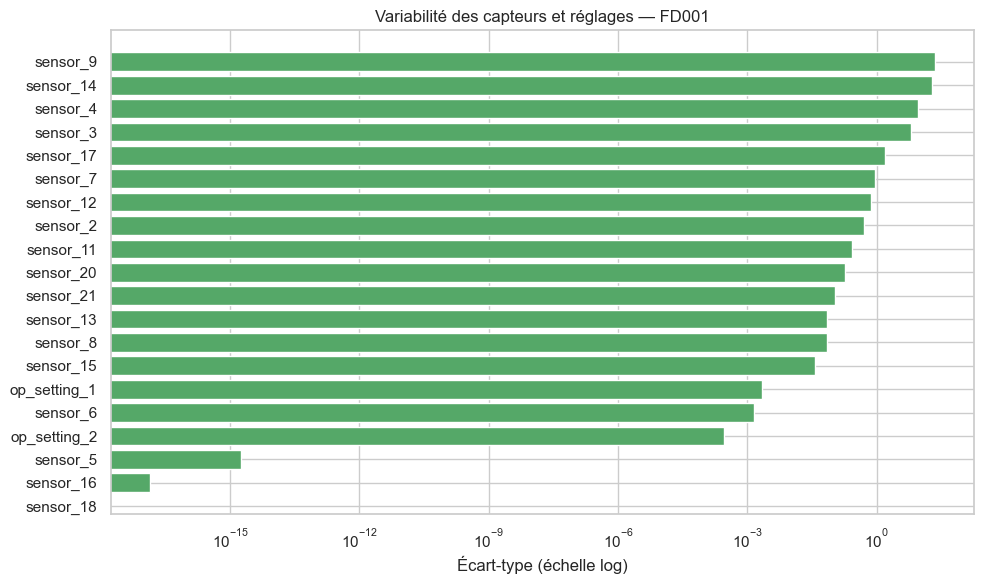

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(variabilite.index, variabilite.replace(0, np.nan).values, color="#55A868")
ax.set_xscale("log")
ax.set_xlabel("Écart-type (échelle log)")
ax.set_title(f"Variabilité des capteurs et réglages — {SUBSET}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "variabilite_capteurs.png")
plt.show()

In [7]:
# Persistance de la liste pour reutilisation dans 02_preparation (source unique de verite)
config_path = PROJECT_ROOT / "config" / "fd001_capteurs_exclus.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(
        {"subset": SUBSET, "seuil_variance": SEUIL_VARIANCE_NULLE, "capteurs_exclus": capteurs_constants},
        f, ensure_ascii=False, indent=2,
    )

print(f"Liste des capteurs exclus sauvegardee dans {config_path}")

Liste des capteurs exclus sauvegardee dans C:\cmapss-prediction-rul\config\fd001_capteurs_exclus.json


## 4. Corrélations entre capteurs

Les capteurs mesurant des grandeurs physiquement liées (température ou pression à des étages voisins du moteur) sont souvent fortement corrélés entre eux — une redondance à garder en tête pour le feature engineering.

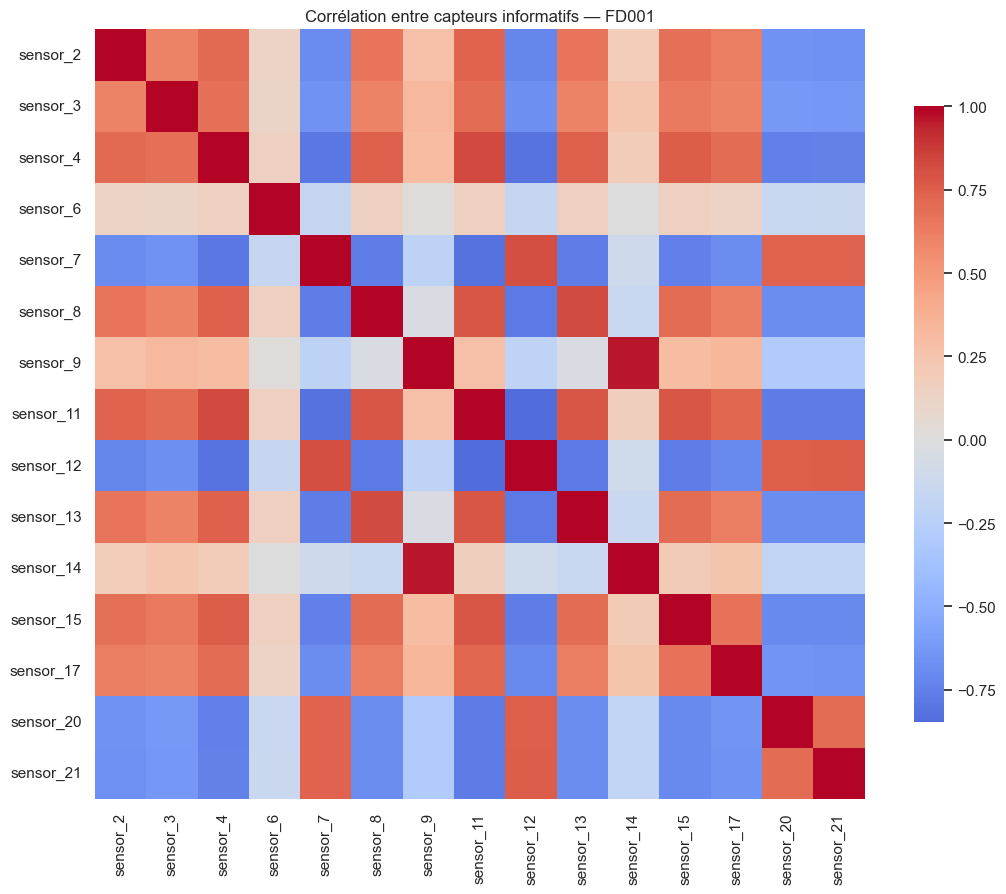

In [8]:
capteurs_informatifs = [c for c in SENSOR_COLUMNS if c not in capteurs_constants]
correlation = df_train[capteurs_informatifs].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(correlation, cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title(f"Corrélation entre capteurs informatifs — {SUBSET}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_capteurs.png")
plt.show()

## 5. Corrélation des capteurs avec la dégradation

On calcule ici une RUL à titre exploratoire uniquement (cycle maximal du moteur moins cycle courant, sans écrêtage) pour identifier les capteurs les plus corrélés à l'approche de la panne. La construction officielle de la cible, avec écrêtage à 125 cycles, se fait dans `02_preparation`.

In [9]:
rul_exploratoire = df_train.groupby("unit_number")["time_in_cycles"].transform("max") - df_train["time_in_cycles"]

correlation_rul = df_train[capteurs_informatifs].corrwith(rul_exploratoire).sort_values()

print("Correlation de chaque capteur avec la RUL (exploratoire) :")
print(correlation_rul)

Correlation de chaque capteur avec la RUL (exploratoire) :
sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
dtype: float64


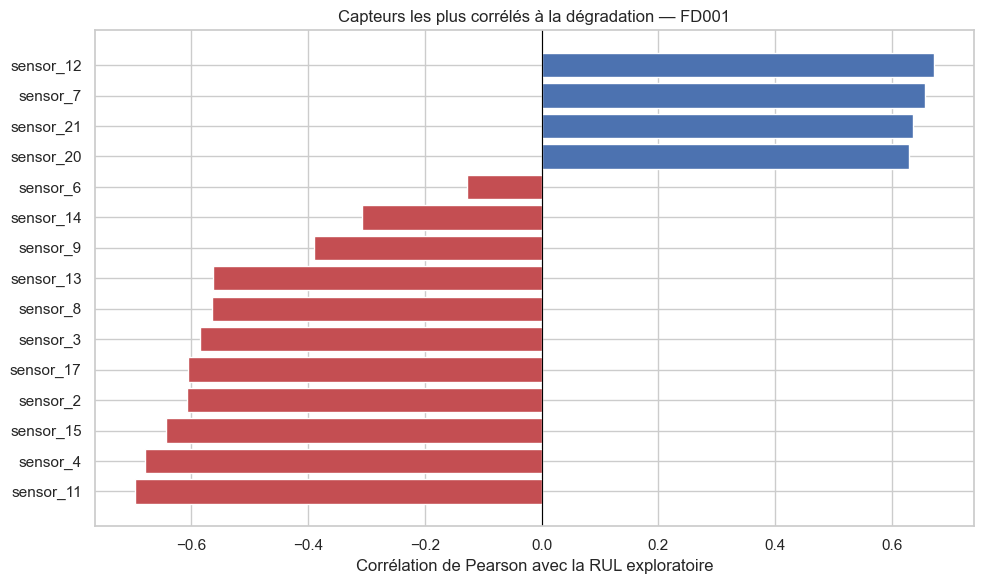

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in correlation_rul.values]
ax.barh(correlation_rul.index, correlation_rul.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Corrélation de Pearson avec la RUL exploratoire")
ax.set_title(f"Capteurs les plus corrélés à la dégradation — {SUBSET}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_capteurs_rul.png")
plt.show()

## 6. Trajectoires tronquées du jeu de test

Contrairement au train (trajectoires complètes jusqu'à la panne), le test s'arrête à un cycle arbitraire avant la panne — c'est la situation réelle qu'on cherche à résoudre : prédire la RUL sans connaître l'instant de panne. On compare ici la distribution des longueurs de trajectoires entre les deux jeux.

       train (duree de vie complete)  test (longueur tronquee)
count                     100.000000                100.000000
mean                      206.310000                130.960000
std                        46.342749                 53.593479
min                       128.000000                 31.000000
25%                       177.000000                 88.750000
50%                       199.000000                133.500000
75%                       229.250000                164.250000
max                       362.000000                303.000000


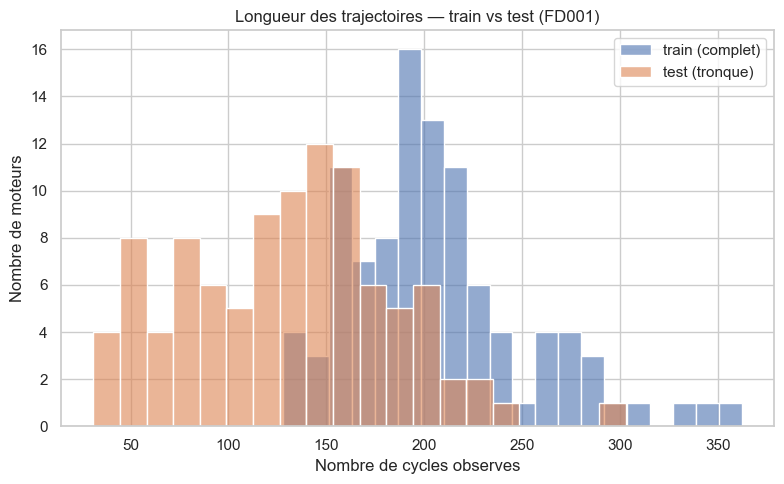

In [11]:
cycles_test = df_test.groupby("unit_number")["time_in_cycles"].max()

comparaison = pd.DataFrame({
    "train (duree de vie complete)": cycles_par_moteur.describe(),
    "test (longueur tronquee)": cycles_test.describe(),
})
print(comparaison)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(cycles_par_moteur, bins=20, color="#4C72B0", alpha=0.6, label="train (complet)", ax=ax)
sns.histplot(cycles_test, bins=20, color="#DD8452", alpha=0.6, label="test (tronque)", ax=ax)
ax.set_xlabel("Nombre de cycles observes")
ax.set_ylabel("Nombre de moteurs")
ax.set_title(f"Longueur des trajectoires — train vs test ({SUBSET})")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "train_vs_test_longueur.png")
plt.show()

## 7. Synthèse et prochaine étape

Cette exploration établit :
- la plage de variation des durées de vie, qui justifie l'écrêtage de la cible à 125 cycles ;
- la liste des capteurs et réglages à variance quasi nulle, à exclure (sauvegardée dans `config/fd001_capteurs_exclus.json`) ;
- les capteurs les plus corrélés à la dégradation, pertinents pour le feature engineering ;
- la nature tronquée du jeu de test, qui structure toute l'évaluation du projet.

**Prochaine étape** : `notebooks/02_preparation/02_construction_cible_rul.ipynb` — construction officielle de la cible RUL (écrêtage à 125), filtrage des capteurs identifiés ici, et normalisation MinMaxScaler par moteur.